In [2]:
!pip install -U ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 49.3 MB/s eta 0:00:00


#CODEX 코드 최종

In [3]:
import os
import gc
import cv2
import math
import time
import glob
import numpy as np
import pandas as pd

from pathlib import Path
from tqdm.auto import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed
from scipy.optimize import linear_sum_assignment
from ultralytics import YOLO

# ============================================================
# Lettuce slot crop generation from best.pt
# - 핵심 변경점:
#   1) 노란 점 기준이 아니라, "빈 원 4개 블록"을 기준틀로 삼는다.
#   2) slot frame을 먼저 고정하고, 검출 결과는 그 틀에 붙인다.
#   3) 2작기에서는 x_pos 고정비율을 버리고 p1~p4를 오른쪽으로 외삽한다.
# - 해석:
#   r=0  : 왼쪽 anchor 블록의 왼쪽 경계
#   r=1  : 왼쪽 anchor 블록의 오른쪽 경계
#   r=2~7: b1/t1 ~ b6/t6의 각 column 중심
# ============================================================

MODEL_PATH = r"/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/model/results/runs/segment/Lettuce_Final_Project/Step1_M_Model_0312/weights/best.pt"
IMG_ROOT = r"/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/2작기/5. 밝기보정/이름변경 후_to 0412"
OUT_ROOT = r"/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/2작기_lettuce/이름변경 후_to 0412/0. crops_to260412"
CSV_LOOKUP_PATH = r"/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/2작기/1. circle_anchor/이름변경 후_to 0412/per_image_results_v4.csv"

IMG_EXTS = ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.tif", "*.tiff", "*.webp")
IMGSZ = 960
CONF_THRES = 0.25
IOU_THRES = 0.50
DEVICE = "cpu"
MAX_DET = 64

PAD_PX = 14
MIN_BOX_W = 20
MIN_BOX_H = 20
MASK_BG = "black"
SAVE_EXT = ".png"

# 2작기 slot frame
# r=2.0 이 첫 번째 lettuce column, 이후 1칸씩 증가
COL_START_R = 2.0
COL_STEP_R = 1.0
NUM_COLS = 6

# y는 기존에 써오던 dynamic y 비율 유지
TOP_ROW_R = 0.28
BOT_ROW_R = 0.95

# CSV가 없을 때만 쓰는 fallback
FALLBACK_X_POS = [0.22, 0.35, 0.48, 0.61, 0.74, 0.87]
FALLBACK_TOP_Y = 0.33
FALLBACK_BOT_Y = 0.72

SLOT_ORDER = [f"t{i}" for i in range(1, NUM_COLS + 1)] + [f"b{i}" for i in range(1, NUM_COLS + 1)]

ROW_SPLIT_R = 0.50
ROW_MARGIN_R = 0.18
PRIMARY_MAX_DIST_R = 0.65
EXTRA_MAX_DIST_R = 1.05
UNASSIGNED_LABEL = "unassigned"
UNASSIGNED_STATUS = "row_guard_rejected"
UNASSIGNED_PART_NO = None
UNASSIGNED_SLOT_NAME = None

USE_BED_SUBFOLDER = True
CHUNK_SIZE = 10
SAVE_EVERY_CHUNK = True
N_SAVE_WORKERS = 8
SKIP_IF_DONE = False

SAVE_OVERLAY = True
OVERLAY_LINE_W = 2
FONT_SCALE = 0.7


def now_hms():
    return time.strftime("%H:%M:%S")


def safe_mkdir(p):
    os.makedirs(p, exist_ok=True)


def list_images_recursive(root, exts=IMG_EXTS):
    root = str(root)
    files = []
    for ext in exts:
        files.extend(glob.glob(os.path.join(root, "**", ext), recursive=True))
    return sorted(list(set(files)))


def parse_base_key(img_path):
    return Path(img_path).stem


def parse_bed_name(base_key):
    parts = base_key.split("_")
    return parts[0] if len(parts) > 0 else "unknown_bed"


def load_csv_lookup(csv_path):
    df = pd.read_csv(csv_path)
    df["base_key"] = df["image_name"].astype(str).apply(lambda x: Path(x).stem)

    keep_cols = [
        "base_key",
        "image_name",
        "p1_x", "p1_y",
        "p2_x", "p2_y",
        "p3_x", "p3_y",
        "p4_x", "p4_y",
        "matched_count",
        "source",
        "notes",
    ]
    for col in ["p1_x", "p1_y", "p2_x", "p2_y", "p3_x", "p3_y", "p4_x", "p4_y", "matched_count"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    out = {}
    for _, row in df[keep_cols].iterrows():
        out[row["base_key"]] = row.to_dict()
    return out


def lerp(a, b, t):
    return a + (b - a) * t


def _make_fallback_anchors(w, h):
    anchors = {}
    for i, xr in enumerate(FALLBACK_X_POS, start=1):
        anchors[f"t{i}"] = (int(round(w * xr)), int(round(h * FALLBACK_TOP_Y)))
        anchors[f"b{i}"] = (int(round(w * xr)), int(round(h * FALLBACK_BOT_Y)))
    return anchors


def make_slot_anchors_slot_frame(base_key, w, h, lookup):
    info = lookup.get(base_key)
    if info is None:
        return _make_fallback_anchors(w, h), {
            "anchor_mode": "fallback_fixed",
            "top_row_r": None,
            "bot_row_r": None,
            "col_start_r": None,
            "col_step_r": None,
        }

    vals = {}
    for k in ["p1_x", "p1_y", "p2_x", "p2_y", "p3_x", "p3_y", "p4_x", "p4_y"]:
        vals[k] = float(info[k]) if pd.notna(info[k]) else None

    if any(v is None for v in vals.values()):
        return _make_fallback_anchors(w, h), {
            "anchor_mode": "fallback_fixed_nan",
            "top_row_r": None,
            "bot_row_r": None,
            "col_start_r": None,
            "col_step_r": None,
        }

    p1 = (vals["p1_x"], vals["p1_y"])
    p2 = (vals["p2_x"], vals["p2_y"])
    p3 = (vals["p3_x"], vals["p3_y"])
    p4 = (vals["p4_x"], vals["p4_y"])

    anchors = {}
    debug_cols = []

    for idx in range(NUM_COLS):
        col_no = idx + 1
        col_r = COL_START_R + COL_STEP_R * idx

        # anchor 블록을 오른쪽으로 외삽한 "column center line"
        tx = lerp(p1[0], p2[0], col_r)
        ty = lerp(p1[1], p2[1], col_r)
        bx = lerp(p4[0], p3[0], col_r)
        by = lerp(p4[1], p3[1], col_r)

        top_ax = lerp(tx, bx, TOP_ROW_R)
        top_ay = lerp(ty, by, TOP_ROW_R)
        bot_ax = lerp(tx, bx, BOT_ROW_R)
        bot_ay = lerp(ty, by, BOT_ROW_R)

        anchors[f"t{col_no}"] = (int(round(top_ax)), int(round(top_ay)))
        anchors[f"b{col_no}"] = (int(round(bot_ax)), int(round(bot_ay)))
        debug_cols.append((col_no, round(col_r, 3), round(top_ax, 2), round(bot_ax, 2)))

    meta = {
        "anchor_mode": "slot_frame_extrapolated_from_p1p4",
        "top_row_r": TOP_ROW_R,
        "bot_row_r": BOT_ROW_R,
        "col_start_r": COL_START_R,
        "col_step_r": COL_STEP_R,
        "matched_count_csv": int(info["matched_count"]) if pd.notna(info["matched_count"]) else None,
        "source_csv": info.get("source"),
        "notes_csv": info.get("notes"),
        "p1_x": p1[0], "p1_y": p1[1],
        "p2_x": p2[0], "p2_y": p2[1],
        "p3_x": p3[0], "p3_y": p3[1],
        "p4_x": p4[0], "p4_y": p4[1],
        "slot_frame_cols": str(debug_cols),
    }
    return anchors, meta


def mask_to_bbox(mask_u8):
    ys, xs = np.where(mask_u8 > 0)
    if len(xs) == 0:
        return None
    return int(xs.min()), int(ys.min()), int(xs.max()), int(ys.max())


def mask_centroid(mask_u8):
    ys, xs = np.where(mask_u8 > 0)
    if len(xs) == 0:
        return None
    return float(xs.mean()), float(ys.mean())


def apply_mask_bg(crop_bgr, crop_mask_u8, mode="black"):
    if mode == "keep":
        return crop_bgr
    bg_val = 0 if mode == "black" else 255
    out = np.full_like(crop_bgr, bg_val)
    m = crop_mask_u8 > 0
    out[m] = crop_bgr[m]
    return out


def build_cost_matrix(det_centers, slot_points):
    cost = np.zeros((len(det_centers), len(slot_points)), dtype=np.float32)
    for i, (cx, cy) in enumerate(det_centers):
        for j, (sx, sy) in enumerate(slot_points):
            cost[i, j] = math.hypot(cx - sx, cy - sy)
    return cost


def get_slot_column_no(slot_name):
    return int(str(slot_name)[1:])


def get_row_pair_points(slot_name, anchors_dict):
    col_no = get_slot_column_no(slot_name)
    return anchors_dict[f"t{col_no}"], anchors_dict[f"b{col_no}"]


def validate_slot_candidate(det_center, slot_name, anchors_dict, max_dist_r):
    cx, cy = det_center
    sx, sy = anchors_dict[slot_name]
    top_pt, bot_pt = get_row_pair_points(slot_name, anchors_dict)

    row_gap = math.hypot(bot_pt[0] - top_pt[0], bot_pt[1] - top_pt[1])
    row_gap = max(row_gap, 1.0)

    split_y = lerp(top_pt[1], bot_pt[1], ROW_SPLIT_R)
    row_margin_px = row_gap * ROW_MARGIN_R
    dist_px = math.hypot(cx - sx, cy - sy)
    max_dist_px = row_gap * max_dist_r

    if slot_name.startswith("t"):
        row_ok = cy <= (split_y + row_margin_px)
    else:
        row_ok = cy >= (split_y - row_margin_px)

    dist_ok = dist_px <= max_dist_px
    return {
        "valid": bool(row_ok and dist_ok),
        "row_ok": bool(row_ok),
        "dist_ok": bool(dist_ok),
        "dist_px": float(dist_px),
        "max_dist_px": float(max_dist_px),
    }


def assign_primary_slots(det_centers, anchors_dict):
    primary = {}
    if len(det_centers) == 0:
        return primary, []

    slot_names = list(anchors_dict.keys())
    slot_points = [anchors_dict[s] for s in slot_names]
    cost = build_cost_matrix(det_centers, slot_points)
    row_ind, col_ind = linear_sum_assignment(cost)

    assigned_det = set()
    for r, c in zip(row_ind, col_ind):
        primary[r] = slot_names[c]
        assigned_det.add(r)

    unassigned = [i for i in range(len(det_centers)) if i not in assigned_det]
    return primary, unassigned


def assign_all_pieces(det_centers, anchors_dict):
    slot_of_det = {}
    part_no_of_det = {}
    reject_reason_of_det = {}
    if len(det_centers) == 0:
        return slot_of_det, part_no_of_det, reject_reason_of_det

    primary_map, initial_unassigned = assign_primary_slots(det_centers, anchors_dict)
    slot_names = list(anchors_dict.keys())
    slot_groups = {s: [] for s in slot_names}
    recheck_det_idxs = list(initial_unassigned)

    for det_idx, slot_name in primary_map.items():
        check = validate_slot_candidate(det_centers[det_idx], slot_name, anchors_dict, PRIMARY_MAX_DIST_R)
        if check["valid"]:
            slot_groups[slot_name].append(det_idx)
            slot_of_det[det_idx] = slot_name
        else:
            recheck_det_idxs.append(det_idx)
            reject_reason_of_det[det_idx] = "primary_row_or_distance_fail"

    for det_idx in recheck_det_idxs:
        cx, cy = det_centers[det_idx]
        candidates = []
        for slot_name in slot_names:
            check = validate_slot_candidate((cx, cy), slot_name, anchors_dict, EXTRA_MAX_DIST_R)
            if check["valid"]:
                candidates.append((slot_name, check["dist_px"]))

        if len(candidates) == 0:
            if det_idx not in reject_reason_of_det:
                reject_reason_of_det[det_idx] = "no_valid_slot_after_guard"
            continue

        candidates.sort(key=lambda x: x[1])
        best_slot = candidates[0][0]
        slot_groups[best_slot].append(det_idx)
        slot_of_det[det_idx] = best_slot
        reject_reason_of_det.pop(det_idx, None)

    for slot_name in slot_names:
        dets = slot_groups[slot_name]
        if len(dets) == 0:
            continue
        dets_sorted = sorted(
            dets,
            key=lambda i: math.hypot(
                det_centers[i][0] - anchors_dict[slot_name][0],
                det_centers[i][1] - anchors_dict[slot_name][1],
            ),
        )
        for k, det_idx in enumerate(dets_sorted, start=1):
            part_no_of_det[det_idx] = k

    return slot_of_det, part_no_of_det, reject_reason_of_det


def draw_overlay(img, det_infos, anchors_dict):
    canvas = img.copy()
    for slot_name, (sx, sy) in anchors_dict.items():
        cv2.circle(canvas, (int(sx), int(sy)), 8, (0, 255, 255), -1)
        cv2.putText(
            canvas,
            slot_name,
            (int(sx) - 16, int(sy) - 12),
            cv2.FONT_HERSHEY_SIMPLEX,
            FONT_SCALE,
            (0, 255, 255),
            2,
            cv2.LINE_AA,
        )
    for d in det_infos:
        x1, y1, x2, y2 = d["bbox"]
        if d["slot_name"] is None or d["part_no"] is None:
            label = UNASSIGNED_LABEL
            color = (0, 0, 255)
        else:
            label = f"{d['slot_name']}_p{d['part_no']:02d}"
            color = (0, 255, 0)
        cv2.rectangle(canvas, (x1, y1), (x2, y2), color, OVERLAY_LINE_W)
        cv2.putText(
            canvas,
            label,
            (x1, max(22, y1 - 6)),
            cv2.FONT_HERSHEY_SIMPLEX,
            FONT_SCALE,
            color,
            2,
            cv2.LINE_AA,
        )
    return canvas


def build_output_paths(base_key, bed_name, slot_name, part_no):
    filename = f"{base_key}_{slot_name}_p{part_no:02d}{SAVE_EXT}"
    out_dir = os.path.join(OUT_ROOT, "crops", bed_name) if USE_BED_SUBFOLDER else os.path.join(OUT_ROOT, "crops_flat")
    safe_mkdir(out_dir)
    return os.path.join(out_dir, filename)


def save_crop_task(task):
    try:
        img = task["img"]
        mask = task["mask"]
        out_path = task["out_path"]
        x1, y1, x2, y2 = task["bbox"]
        x1p = max(0, x1 - PAD_PX)
        y1p = max(0, y1 - PAD_PX)
        x2p = min(img.shape[1] - 1, x2 + PAD_PX)
        y2p = min(img.shape[0] - 1, y2 + PAD_PX)
        if (x2p - x1p + 1) < MIN_BOX_W or (y2p - y1p + 1) < MIN_BOX_H:
            return {"ok": False, "out_path": out_path, "reason": "too_small"}
        crop = img[y1p:y2p + 1, x1p:x2p + 1].copy()
        crop_mask = mask[y1p:y2p + 1, x1p:x2p + 1].copy()
        crop2 = apply_mask_bg(crop, crop_mask, MASK_BG)
        cv2.imwrite(out_path, crop2)
        return {"ok": True, "out_path": out_path, "skipped": False}
    except Exception as e:
        return {"ok": False, "out_path": task.get("out_path", ""), "reason": str(e)}


def process_one_image(img_path, model, lookup):
    base_key = parse_base_key(img_path)
    bed_name = parse_bed_name(base_key)
    img = cv2.imread(img_path)
    if img is None:
        return {
            "meta_rows": [],
            "n_det": 0,
            "n_saved": 0,
            "n_fail": 1,
            "overlay_path": None,
            "error": f"cv2.imread failed: {img_path}",
        }

    h, w = img.shape[:2]
    anchors, anchor_meta = make_slot_anchors_slot_frame(base_key, w, h, lookup)

    results = model.predict(
        source=img,
        imgsz=IMGSZ,
        conf=CONF_THRES,
        iou=IOU_THRES,
        device=DEVICE,
        max_det=MAX_DET,
        retina_masks=True,
        verbose=False,
    )

    if len(results) == 0 or results[0].masks is None or results[0].boxes is None or len(results[0].boxes) == 0:
        meta_row = {
            "image_path": img_path,
            "base_key": base_key,
            "bed_name": bed_name,
            "slot_name": None,
            "part_no": None,
            "crop_filename": None,
            "crop_path": None,
            "conf": None,
            "cls": None,
            "cx": None,
            "cy": None,
            "bbox_x1": None,
            "bbox_y1": None,
            "bbox_x2": None,
            "bbox_y2": None,
            "bbox_w": None,
            "bbox_h": None,
            "area_px": None,
            "mask_pixels": None,
            "is_primary": None,
            "n_det_in_image": 0,
            "status": "no_detection",
            **anchor_meta,
        }
        return {"meta_rows": [meta_row], "n_det": 0, "n_saved": 0, "n_fail": 0, "overlay_path": None, "error": None}

    r = results[0]
    xyxy = r.boxes.xyxy.detach().cpu().numpy()
    confs = r.boxes.conf.detach().cpu().numpy() if r.boxes.conf is not None else np.zeros(len(xyxy), dtype=np.float32)
    clss = r.boxes.cls.detach().cpu().numpy() if r.boxes.cls is not None else np.zeros(len(xyxy), dtype=np.float32)
    masks_small = r.masks.data.detach().cpu().numpy()

    masks = []
    det_centers = []
    bbox_list = []

    for i in range(len(masks_small)):
        m = masks_small[i]
        if m.dtype != np.uint8:
            m = (m > 0.5).astype(np.uint8) * 255
        else:
            m = (m > 0).astype(np.uint8) * 255
        if m.shape[:2] != (h, w):
            m = cv2.resize(m, (w, h), interpolation=cv2.INTER_NEAREST)
        bb = mask_to_bbox(m)
        if bb is None:
            x1, y1, x2, y2 = map(int, xyxy[i])
            bb = (
                max(0, min(w - 1, x1)),
                max(0, min(h - 1, y1)),
                max(0, min(w - 1, x2)),
                max(0, min(h - 1, y2)),
            )
            cx, cy = (bb[0] + bb[2]) / 2.0, (bb[1] + bb[3]) / 2.0
        else:
            cen = mask_centroid(m)
            if cen is None:
                x1, y1, x2, y2 = bb
                cx, cy = (x1 + x2) / 2.0, (y1 + y2) / 2.0
            else:
                cx, cy = cen
        masks.append(m)
        det_centers.append((cx, cy))
        bbox_list.append(bb)

    slot_of_det, part_no_of_det, reject_reason_of_det = assign_all_pieces(det_centers, anchors)

    save_tasks = []
    meta_rows = []
    det_infos = []

    for i in range(len(masks)):
        x1, y1, x2, y2 = map(int, bbox_list[i])
        cx, cy = det_centers[i]
        slot_name = slot_of_det.get(i, UNASSIGNED_SLOT_NAME)
        part_no = part_no_of_det.get(i, UNASSIGNED_PART_NO)
        reject_reason = reject_reason_of_det.get(i, None)
        is_primary = part_no == 1 if part_no is not None else False

        if slot_name is None or part_no is None:
            status = reject_reason if reject_reason is not None else UNASSIGNED_STATUS
            out_path = None
            crop_filename = None
        else:
            out_path = build_output_paths(base_key, bed_name, slot_name, part_no)
            crop_filename = os.path.basename(out_path)
            status = "ok"
            save_tasks.append({"img": img, "mask": masks[i], "out_path": out_path, "bbox": (x1, y1, x2, y2)})

        meta_rows.append({
            "image_path": img_path,
            "base_key": base_key,
            "bed_name": bed_name,
            "slot_name": slot_name,
            "part_no": part_no,
            "crop_filename": crop_filename,
            "crop_path": out_path,
            "conf": float(confs[i]) if i < len(confs) else None,
            "cls": int(clss[i]) if i < len(clss) else None,
            "cx": float(cx),
            "cy": float(cy),
            "bbox_x1": int(x1),
            "bbox_y1": int(y1),
            "bbox_x2": int(x2),
            "bbox_y2": int(y2),
            "bbox_w": int(x2 - x1 + 1),
            "bbox_h": int(y2 - y1 + 1),
            "area_px": int((x2 - x1 + 1) * (y2 - y1 + 1)),
            "mask_pixels": int((masks[i] > 0).sum()),
            "is_primary": int(is_primary),
            "n_det_in_image": int(len(masks)),
            "status": status,
            "slot_guard_reason": reject_reason,
            **anchor_meta,
        })
        det_infos.append({"bbox": (x1, y1, x2, y2), "slot_name": slot_name, "part_no": part_no})

    n_saved = 0
    n_fail = 0
    if len(save_tasks) > 0:
        with ThreadPoolExecutor(max_workers=N_SAVE_WORKERS) as ex:
            futures = [ex.submit(save_crop_task, t) for t in save_tasks]
            for fut in as_completed(futures):
                rr = fut.result()
                if rr["ok"]:
                    n_saved += 1
                else:
                    n_fail += 1

    overlay_path = None
    if SAVE_OVERLAY:
        overlay_dir = os.path.join(OUT_ROOT, "overlay", bed_name)
        safe_mkdir(overlay_dir)
        overlay_path = os.path.join(overlay_dir, f"{base_key}_overlay.jpg")
        overlay = draw_overlay(img, det_infos, anchors)
        cv2.imwrite(overlay_path, overlay)

    del img, results, r, masks_small, masks
    gc.collect()
    return {
        "meta_rows": meta_rows,
        "n_det": int(len(bbox_list)),
        "n_saved": int(n_saved),
        "n_fail": int(n_fail),
        "overlay_path": overlay_path,
        "error": None,
    }


def save_chunk_csv(rows, chunk_idx):
    if len(rows) == 0:
        return None
    chunk_dir = os.path.join(OUT_ROOT, "csv_chunks")
    safe_mkdir(chunk_dir)
    out_csv = os.path.join(chunk_dir, f"slot_crop_meta_chunk_{chunk_idx:04d}.csv")
    pd.DataFrame(rows).to_csv(out_csv, index=False, encoding="utf-8-sig")
    return out_csv


def merge_chunk_csvs(final_csv_path):
    chunk_dir = os.path.join(OUT_ROOT, "csv_chunks")
    csvs = sorted(glob.glob(os.path.join(chunk_dir, "slot_crop_meta_chunk_*.csv")))
    if len(csvs) == 0:
        return None
    dfs = [pd.read_csv(p) for p in csvs]
    pd.concat(dfs, axis=0, ignore_index=True).to_csv(final_csv_path, index=False, encoding="utf-8-sig")
    return final_csv_path


def main():
    print(f"[{now_hms()}] [START slot_frame_final]")
    safe_mkdir(OUT_ROOT)
    safe_mkdir(os.path.join(OUT_ROOT, "crops"))
    safe_mkdir(os.path.join(OUT_ROOT, "overlay"))
    safe_mkdir(os.path.join(OUT_ROOT, "csv_chunks"))

    lookup = load_csv_lookup(CSV_LOOKUP_PATH)
    print(f"[INFO] csv lookup rows: {len(lookup)}")

    img_paths = list_images_recursive(IMG_ROOT)
    print(f"[INFO] found images: {len(img_paths)}")
    if len(img_paths) == 0:
        raise RuntimeError("No input images found.")

    model = YOLO(MODEL_PATH)
    total_imgs = len(img_paths)
    all_rows = []
    chunk_idx = 1

    for start in tqdm(range(0, total_imgs, CHUNK_SIZE), desc="chunks"):
        batch = img_paths[start:start + CHUNK_SIZE]
        for img_path in tqdm(batch, leave=False, desc=f"chunk {chunk_idx}"):
            rr = process_one_image(img_path, model, lookup)
            all_rows.extend(rr["meta_rows"])

        if SAVE_EVERY_CHUNK and len(all_rows) > 0:
            save_chunk_csv(all_rows, chunk_idx)
            all_rows = []
        chunk_idx += 1

    final_csv = os.path.join(OUT_ROOT, "slot_crop_meta_all.csv")
    if SAVE_EVERY_CHUNK:
        merge_chunk_csvs(final_csv)
    else:
        pd.DataFrame(all_rows).to_csv(final_csv, index=False, encoding="utf-8-sig")

    print(f"[DONE] final csv: {final_csv}")
    print(f"[DONE] anchor frame mode: p1~p4 extrapolated slot frame")
    print(f"[DONE] column ratios: {[COL_START_R + COL_STEP_R * i for i in range(NUM_COLS)]}")


if __name__ == "__main__":
    main()


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
[13:57:22] [START slot_frame_final]
[INFO] csv lookup rows: 2358
[INFO] found images: 1255


chunks:   0%|          | 0/126 [00:00<?, ?it/s]

chunk 1:   0%|          | 0/10 [00:00<?, ?it/s]

chunk 2:   0%|          | 0/10 [00:00<?, ?it/s]

chunk 3:   0%|          | 0/10 [00:00<?, ?it/s]

...

chunk 123:   0%|          | 0/10 [00:00<?, ?it/s]

chunk 124:   0%|          | 0/10 [00:00<?, ?it/s]

chunk 125:   0%|          | 0/10 [00:00<?, ?it/s]

chunk 126:   0%|          | 0/5 [00:00<?, ?it/s]

[DONE] final csv: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/2작기_lettuce/이름변경 후_to 0412/0. crops_to260412/slot_crop_meta_all.csv
[DONE] anchor frame mode: p1~p4 extrapolated slot frame
[DONE] column ratios: [2.0, 3.0, 4.0, 5.0, 6.0, 7.0]


#잠깐만. 이미지 1장만 오늘은 해보자

TEST_IMG_PATH: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/2작기/5. 밝기보정/이름변경 후_to 0412/bed01_20260320_103511_cam2_rf.jpg
[INFO] DEVICE set to: cpu

[RESULT SUMMARY]
n_det   : 6
n_saved : 5
n_fail  : 0
error   : None
overlay : /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/2작기_lettuce/이름변경 후_to 0412/0. crops_to260412/overlay/bed01/bed01_20260320_103511_cam2_rf_overlay.jpg

[METADATA HEAD]


,image_path,base_key,bed_name,slot_name,part_no,crop_filename,crop_path,conf,cls,cx,...,notes_csv,p1_x,p1_y,p2_x,p2_y,p3_x,p3_y,p4_x,p4_y,slot_frame_cols
0,/content/drive/Othercomputers/내 컴퓨터/새 포...,bed01_20260320_103511_cam2_rf,bed01,b3,1.0,bed01_20260320_103511_cam2_rf_b3_p01.png,/content/drive/Othercomputers/내 컴퓨터/새 포...,0.918917,0,1056.064435,...,template_corrected_with_4,158.743134,48.934406,393.035919,49.71545,289.793793,189.236649,29.92296,190.315125,"[(1, 2.0, 605.58, 553.55), (2, 3.0, 847.04, 81..."
1,/content/drive/Othercomputers/내 컴퓨터/새 포...,bed01_20260320_103511_cam2_rf,bed01,b1,1.0,bed01_20260320_103511_cam2_rf_b1_p01.png,/content/drive/Othercomputers/내 컴퓨터/새 포...,0.894654,0,551.570566,...,template_corrected_with_4,158.743134,48.934406,393.035919,49.71545,289.793793,189.236649,29.92296,190.315125,"[(1, 2.0, 605.58, 553.55), (2, 3.0, 847.04, 81..."
2,/content/drive/Othercomputers/내 컴퓨터/새 포...,bed01_20260320_103511_cam2_rf,bed01,b5,1.0,bed01_20260320_103511_cam2_rf_b5_p01.png,/content/drive/Othercomputers/내 컴퓨터/새 포...,0.871542,0,1573.812562,...,template_corrected_with_4,158.743134,48.934406,393.035919,49.71545,289.793793,189.236649,29.92296,190.315125,"[(1, 2.0, 605.58, 553.55), (2, 3.0, 847.04, 81..."
3,/content/drive/Othercomputers/내 컴퓨터/새 포...,bed01_20260320_103511_cam2_rf,bed01,None,NaN,None,None,0.807820,0,2028.801160,...,template_corrected_with_4,158.743134,48.934406,393.035919,49.71545,289.793793,189.236649,29.92296,190.315125,"[(1, 2.0, 605.58, 553.55), (2, 3.0, 847.04, 81..."
4,/content/drive/Othercomputers/내 컴퓨터/새 포...,bed01_20260320_103511_cam2_rf,bed01,t2,1.0,bed01_20260320_103511_cam2_rf_t2_p01.png,/content/drive/Othercomputers/내 컴퓨터/새 포...,0.746281,0,840.150908,...,template_corrected_with_4,158.743134,48.934406,393.035919,49.71545,289.793793,189.236649,29.92296,190.315125,"[(1, 2.0, 605.58, 553.55), (2, 3.0, 847.04, 81..."
5,/content/drive/Othercomputers/내 컴퓨터/새 포...,bed01_20260320_103511_cam2_rf,bed01,t4,1.0,bed01_20260320_103511_cam2_rf_t4_p01.png,/content/drive/Othercomputers/내 컴퓨터/새 포...,0.722095,0,1309.246156,...,template_corrected_with_4,158.743134,48.934406,393.035919,49.71545,289.793793,189.236649,29.92296,190.315125,"[(1, 2.0, 605.58, 553.55), (2, 3.0, 847.04, 81..."


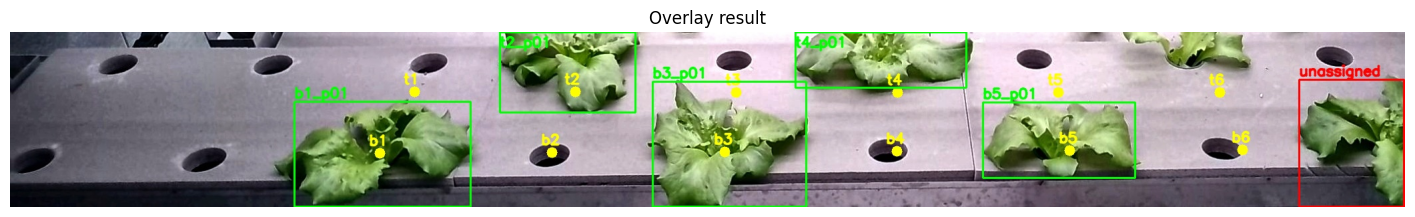

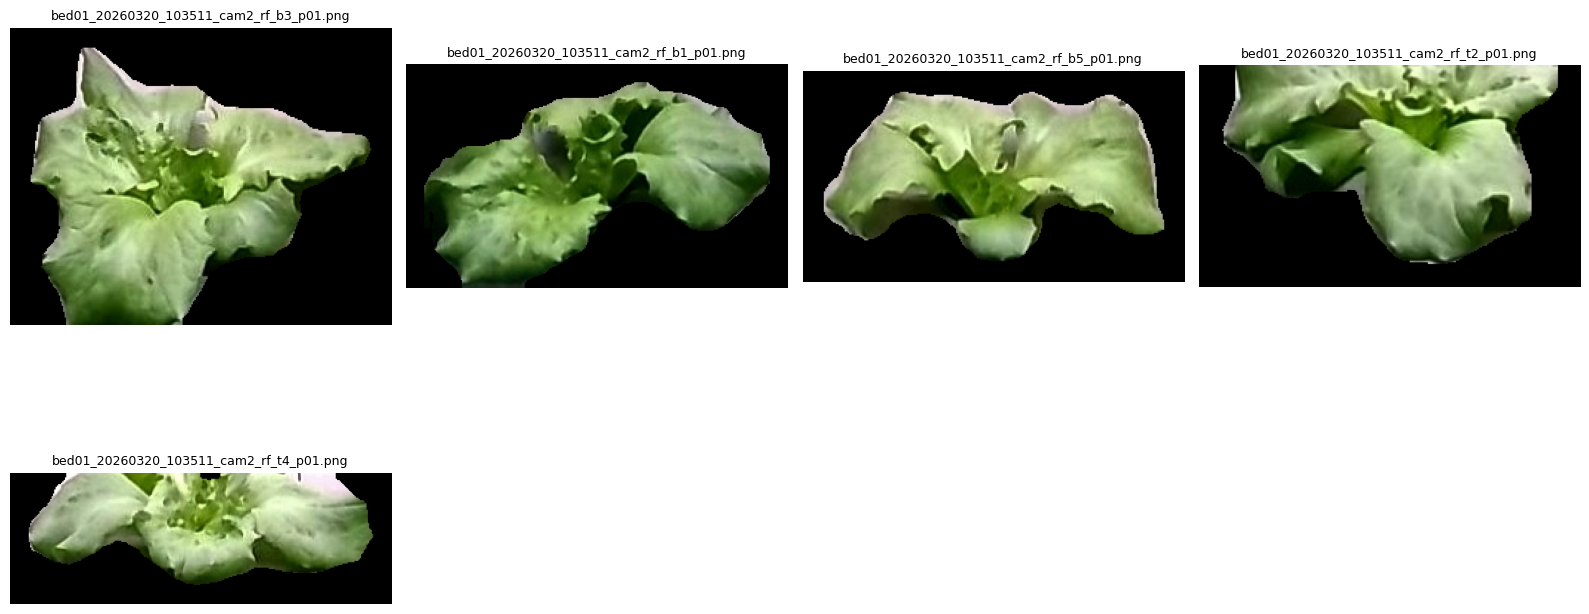

In [6]:
from matplotlib import pyplot as plt
from pathlib import Path
import os
import cv2

# 1) 테스트할 이미지 1장 지정
TEST_IMG_PATH = r"/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/2작기/5. 밝기보정/이름변경 후_to 0412/bed01_20260320_103511_cam2_rf.jpg"

# 또는 자동으로 첫 장 가져오려면 이거 사용
# img_list = list_images_recursive(IMG_ROOT)
# TEST_IMG_PATH = img_list[0]

print("TEST_IMG_PATH:", TEST_IMG_PATH)

# Fix: Set DEVICE to 'cpu' as GPU is not available
DEVICE = 'cpu'
print(f"[INFO] DEVICE set to: {DEVICE}")

# 2) 모델 로드
model = YOLO(MODEL_PATH)

# CSV lookup 로드
lookup = load_csv_lookup(CSV_LOOKUP_PATH)

# 3) 1장 처리
ret = process_one_image(TEST_IMG_PATH, model, lookup)

print("\n[RESULT SUMMARY]")
print("n_det   :", ret["n_det"])
print("n_saved :", ret["n_saved"])
print("n_fail  :", ret["n_fail"])
print("error   :", ret["error"])
print("overlay :", ret["overlay_path"])

# 4) metadata 미리 보기
df_test = pd.DataFrame(ret["meta_rows"])
print("\n[METADATA HEAD]")
display(df_test.head(20))

# 5) overlay 출력
if ret["overlay_path"] is not None and os.path.exists(ret["overlay_path"]):
    overlay_bgr = cv2.imread(ret["overlay_path"])
    overlay_rgb = cv2.cvtColor(overlay_bgr, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(18, 8))
    plt.imshow(overlay_rgb)
    plt.title("Overlay result")
    plt.axis("off")
    plt.show()
else:
    print("overlay image not found")

# 6) 저장된 crop 몇 장 출력
crop_paths = [p for p in df_test["crop_path"].dropna().tolist() if os.path.exists(p)]
crop_paths = crop_paths[:12]   # 최대 12장만 보기

if len(crop_paths) == 0:
    print("saved crop image not found")
else:
    n = len(crop_paths)
    cols = 4
    rows = (n + cols - 1) // cols

    plt.figure(figsize=(16, 4 * rows))
    for i, cp in enumerate(crop_paths, start=1):
        img_bgr = cv2.imread(cp)
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        plt.subplot(rows, cols, i)
        plt.imshow(img_rgb)
        plt.title(Path(cp).name, fontsize=9)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

#상추 재 필터링 (결구판단용)

In [7]:
# ============================================================
# QC filter + copy lettuce crops by date
# - input : slot_crop_metadata_all.csv
# - output: 날짜별 폴더에 통과 crop 이미지 복사 + qc 결과 csv 저장
# ============================================================

import os
import re
import math
import shutil
import pandas as pd
from pathlib import Path
from tqdm.auto import tqdm

# ============================================================
# 1) 경로 설정 (여기만 수정)
# ============================================================
META_CSV = r"/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/2작기_lettuce/이름변경 후_to 0412/0. crops_to260412/slot_crop_meta_all.csv"
QC_OUT_ROOT = r"/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/2작기_lettuce/이름변경 후_to 0412/1. crops_filter"

# ============================================================
# 2) QC 기준 설정 (여기만 수정)
# ============================================================
MIN_DATE = 260407          # 이 날짜 이상만 사용
MIN_BBOX_Y1 = 100          # bbox_y1 < 100 이면 제외
MIN_AR = 0.50             # aspect_ratio = bbox_w / bbox_h 최소
MAX_AR = 2.00             # aspect_ratio 최대
ONLY_PRIMARY = False      # True면 is_primary==1 만 사용
KEEP_STATUSES = ["ok"]   # status가 이 값들인 행만 사용

# 파일 존재 여부 확인
CHECK_FILE_EXISTS = True

# 복사 방식
COPY_MODE = "copy"       # "copy" 또는 "move" (보통 copy 유지)

# 결과 저장
SAVE_FILTERED_CSV = True
SAVE_EXCLUDED_CSV = True


In [8]:

# ============================================================
# 3) 유틸 함수
# ============================================================
def safe_mkdir(p):
    os.makedirs(p, exist_ok=True)


def to_int_safe(x):
    try:
        if pd.isna(x):
            return None
        return int(float(x))
    except:
        return None


def parse_date_from_basekey(base_key):
    """
    예: bed13_20251224_074242_cam2 -> 251224 반환
    """
    if pd.isna(base_key):
        return None
    m = re.search(r"_(\d{8})_", str(base_key))
    if not m:
        return None
    yyyymmdd = m.group(1)
    return int(yyyymmdd[2:])  # 20251224 -> 251224


def file_exists_safe(p):
    try:
        return isinstance(p, str) and len(p) > 0 and os.path.exists(p)
    except:
        return False


def copy_or_move(src, dst, mode="copy"):
    safe_mkdir(os.path.dirname(dst))
    if mode == "move":
        shutil.move(src, dst)
    else:
        shutil.copy2(src, dst)


# ============================================================
# 4) 메타 csv 로드
# ============================================================
print("[INFO] loading:", META_CSV)
df = pd.read_csv(META_CSV)
print("[INFO] rows:", len(df))
print("[INFO] columns:", list(df.columns))

# 필수 컬럼 확인
required_cols = ["base_key", "crop_path", "bbox_y1", "bbox_w", "bbox_h"]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"필수 컬럼 없음: {missing_cols}")

# ============================================================
# 5) 날짜 / aspect_ratio / 파일존재 컬럼 준비
# ============================================================
if "date_6" not in df.columns:
    df["date_6"] = df["base_key"].apply(parse_date_from_basekey)

if "aspect_ratio_calc" not in df.columns:
    df["aspect_ratio_calc"] = df["bbox_w"] / df["bbox_h"]

# 기존 aspect_ratio 컬럼이 있어도 여기선 계산값을 기본으로 사용
# 이유: crop qc에서는 실제 bbox_w, bbox_h 기반이 더 명확함

df["bbox_y1_int"] = df["bbox_y1"].apply(to_int_safe)

df["file_exists"] = df["crop_path"].apply(file_exists_safe) if CHECK_FILE_EXISTS else True

# ============================================================
# 6) 제외 사유 기록용 함수
# ============================================================
def get_exclude_reason(row):
    date_6 = row.get("date_6")
    bbox_y1 = row.get("bbox_y1_int")
    ar = row.get("aspect_ratio_calc")
    status = row.get("status")
    is_primary = row.get("is_primary")
    exists = row.get("file_exists")

    if pd.isna(date_6) or date_6 is None:
        return "date_parse_fail"
    if int(date_6) < MIN_DATE:
        return "date_too_early"
    if pd.isna(bbox_y1) or bbox_y1 is None:
        return "bbox_y1_missing"
    if int(bbox_y1) < MIN_BBOX_Y1:
        return "bbox_y1_too_small"
    if pd.isna(ar):
        return "aspect_ratio_missing"
    if ar < MIN_AR:
        return "aspect_ratio_too_tall"
    if ar > MAX_AR:
        return "aspect_ratio_too_wide"
    if KEEP_STATUSES is not None and len(KEEP_STATUSES) > 0:
        if str(status) not in KEEP_STATUSES:
            return "status_filtered"
    if ONLY_PRIMARY:
        try:
            if int(is_primary) != 1:
                return "not_primary"
        except:
            return "not_primary"
    if CHECK_FILE_EXISTS and not exists:
        return "file_missing"
    return "keep"


# ============================================================
# 7) QC 적용
# ============================================================
df["qc_reason"] = df.apply(get_exclude_reason, axis=1)
df_keep = df[df["qc_reason"] == "keep"].copy()
df_excl = df[df["qc_reason"] != "keep"].copy()

print("\n[QC SUMMARY]")
print("keep rows   :", len(df_keep))
print("exclude rows:", len(df_excl))
print("\n[EXCLUDE REASONS]")
print(df["qc_reason"].value_counts(dropna=False))

# ============================================================
# 8) 날짜별 폴더 복사 저장
# ============================================================
safe_mkdir(QC_OUT_ROOT)

copied = 0
copy_fail = 0
failed_logs = []

for _, row in tqdm(df_keep.iterrows(), total=len(df_keep), desc="copy by date"):
    src = row["crop_path"]
    date_6 = int(row["date_6"])
    fname = os.path.basename(src)

    out_dir = os.path.join(QC_OUT_ROOT, str(date_6))
    safe_mkdir(out_dir)
    dst = os.path.join(out_dir, fname)

    try:
        copy_or_move(src, dst, mode=COPY_MODE)
        copied += 1
    except Exception as e:
        copy_fail += 1
        failed_logs.append({
            "crop_path": src,
            "out_path": dst,
            "error": str(e)
        })

print("\n[COPY SUMMARY]")
print("copied   :", copied)
print("copy_fail:", copy_fail)
print("QC_OUT_ROOT:", QC_OUT_ROOT)

# ============================================================
# 9) 결과 csv 저장
# ============================================================
if SAVE_FILTERED_CSV:
    out_keep_csv = os.path.join(QC_OUT_ROOT, "qc_keep.csv")
    df_keep.to_csv(out_keep_csv, index=False, encoding="utf-8-sig")
    print("saved:", out_keep_csv)

if SAVE_EXCLUDED_CSV:
    out_excl_csv = os.path.join(QC_OUT_ROOT, "qc_excluded.csv")
    df_excl.to_csv(out_excl_csv, index=False, encoding="utf-8-sig")
    print("saved:", out_excl_csv)

if len(failed_logs) > 0:
    out_fail_csv = os.path.join(QC_OUT_ROOT, "copy_failed.csv")
    pd.DataFrame(failed_logs).to_csv(out_fail_csv, index=False, encoding="utf-8-sig")
    print("saved:", out_fail_csv)

# 날짜별 개수 요약
summary = (
    df_keep.groupby("date_6")
    .size()
    .reset_index(name="n_keep")
    .sort_values("date_6")
)
out_summary_csv = os.path.join(QC_OUT_ROOT, "qc_keep_summary_by_date.csv")
summary.to_csv(out_summary_csv, index=False, encoding="utf-8-sig")
print("saved:", out_summary_csv)

print("\n[DONE]")

[INFO] loading: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/2작기_lettuce/이름변경 후_to 0412/0. crops_to260412/slot_crop_meta_all.csv
[INFO] rows: 14516
[INFO] columns: ['image_path', 'base_key', 'bed_name', 'slot_name', 'part_no', 'crop_filename', 'crop_path', 'conf', 'cls', 'cx', 'cy', 'bbox_x1', 'bbox_y1', 'bbox_x2', 'bbox_y2', 'bbox_w', 'bbox_h', 'area_px', 'mask_pixels', 'is_primary', 'n_det_in_image', 'status', 'slot_guard_reason', 'anchor_mode', 'top_row_r', 'bot_row_r', 'col_start_r', 'col_step_r', 'matched_count_csv', 'source_csv', 'notes_csv', 'p1_x', 'p1_y', 'p2_x', 'p2_y', 'p3_x', 'p3_y', 'p4_x', 'p4_y', 'slot_frame_cols']

[QC SUMMARY]
keep rows   : 39
exclude rows: 14477

[EXCLUDE REASONS]
qc_reason
date_too_early       11386
bbox_y1_too_small     3081
keep                    39
status_filtered          6
bbox_y1_missing          4
Name: count, dtype: int64


copy by date:   0%|          | 0/39 [00:00<?, ?it/s]


[COPY SUMMARY]
copied   : 39
copy_fail: 0
QC_OUT_ROOT: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/2작기_lettuce/이름변경 후_to 0412/1. crops_filter
saved: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/2작기_lettuce/이름변경 후_to 0412/1. crops_filter/qc_keep.csv
saved: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/2작기_lettuce/이름변경 후_to 0412/1. crops_filter/qc_excluded.csv
saved: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/2작기_lettuce/이름변경 후_to 0412/1. crops_filter/qc_keep_summary_by_date.csv

[DONE]
